## 1. Load And Explore Audio Dataset
* Dataset: [MINDS-14](https://huggingface.co/datasets/PolyAI/minds14)
  * It contains recordings of people asking an e-banking system questions in several languages and dialects.
  * To load the MINDS-14 dataset, we need to copy the dataset’s identifier on the Hub (PolyAI/minds14) and pass it to the `load_dataset` function.
  * For this practice, we’re only interested in the Australian subset (en-AU) of the data, and limit it to the training split.

In [ ]:
!pip install datasets[audio] soundfile librosa torchcodec

In [ ]:
from datasets import load_dataset, Audio

minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
# tells the dataset to decode audio eagerly into a numpy array when you access an example,
# instead of returning an AudioDecoder object.
minds = minds.cast_column("audio", Audio())

minds

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 654
})

* The dataset contains 654 audio files, each of which is accompanied by a transcription, an English translation, and a label indicating the intent behind the person’s query.

In [ ]:
example = minds[0]
example

{'path': 'en-AU~PAY_BILL/response_4.wav',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x788f45601700>,
 'transcription': 'I would like to pay my electricity bill using my card can you please assist',
 'english_transcription': 'I would like to pay my electricity bill using my card can you please assist',
 'intent_class': 13,
 'lang_id': 2}

In [ ]:
samples = minds[0]["audio"].get_all_samples()

audio_dict = {
    "path": minds[0]["path"],
    "array": samples.data.numpy().squeeze(),
    "sampling_rate": samples.sample_rate
}
audio_dict

{'path': 'en-AU~PAY_BILL/response_4.wav',
 'array': array([ 0.        ,  0.00024414, -0.00024414, ..., -0.00024414,
         0.00024414,  0.0012207 ], dtype=float32),
 'sampling_rate': 8000}

* `path`: the path to the audio file (*.wav in this case).
* `array`: The decoded audio data, represented as a 1-dimensional NumPy array.
* `sampling_rate`. The sampling rate of the audio file (8,000 Hz in this example).

In [ ]:
# The intent_class is a classification category of the audio recording
id2label = minds.features["intent_class"].int2str
id2label(example["intent_class"])

'pay_bill'

In [ ]:
# Remove irrelevant features
'''
features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
'''

columns_to_remove = ["lang_id", "english_transcription"]
minds = minds.remove_columns(columns_to_remove)

minds

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 654
})

In [ ]:
# Listen to a few examples

import gradio as gr
def generate_audio():
    example = minds.shuffle()[0]
    audio = example["audio"]
    return (
        audio["sampling_rate"],
        audio["array"],
    ), id2label(example["intent_class"])


with gr.Blocks() as demo:  # creates a Gradio app container
    with gr.Column():      # arranges everything inside it vertically
        for _ in range(2):
            audio, label = generate_audio()
            output = gr.Audio(audio, label=label)

demo.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bea46dbfc1668ebf33.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://bea46dbfc1668ebf33.gradio.live


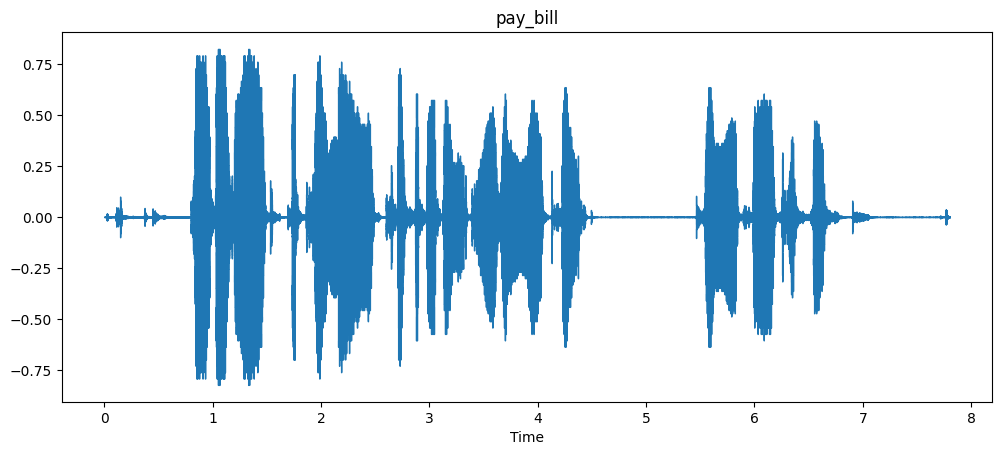

In [ ]:
# Visualize some of the examples

import librosa
import matplotlib.pyplot as plt
import librosa.display

array = example["audio"]["array"]
sampling_rate = example["audio"]["sampling_rate"]
title = id2label(example["intent_class"])

plt.figure().set_figwidth(12)
plt.title(title)
librosa.display.waveshow(array, sr=sampling_rate)

## 2. Preprocessing Audio Dataset

### 2.1 Resampling the audio data
* The sampling rate of the raw audio is not  always the sampling rate expected by a model you plan to train.
* Most of the available pretrained models have been pretrained on audio datasets at a sampling rate of 16 kHz.
* Datasets’ `cast_column` method:
  * This operation does not change the audio in-place.
  * It resamples the audio examples on the fly when they are loaded.

In [ ]:
from datasets import load_dataset, Audio

minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
minds = minds.cast_column("audio", Audio(sampling_rate=16_000))

print(f"resampled rate: {minds[5]['audio']['sampling_rate']}")

resampled rate: 16000


### 2.2 Filtering the dataset
* We might want to filter out any examples longer than 20s to prevent out-of-memory errors when training a model.
* We can do this by using the Datasets’ `filter` method and passing a function with filtering logic to it.

In [ ]:
import librosa

MAX_DURATION_IN_SECONDS = 20.0

def is_audio_length_in_range(input_length):
    return input_length < MAX_DURATION_IN_SECONDS
new_column = [
    librosa.get_duration(y=x["array"], sr=x["sampling_rate"]) for x in minds["audio"]
]
minds =minds.add_column("duration", new_column)

# use Datasets' `filter` method to apply the filtering function
minds = minds.filter(is_audio_length_in_range, input_columns=["duration"])

# remove the temporary helper column
minds = minds.remove_columns(["duration"])
minds

# original num_rows: 654

Flattening the indices:   0%|          | 0/624 [00:00<?, ? examples/s]

Filter:   0%|          | 0/624 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 624
})

### 2.3 Pre-processing audio data
* The raw audio data comes as an array of *sample values*.,
* We expect the raw data to be converted into input features.
* For every supported audio model, *Transformers* offer a **feature extractor class** that can convert raw audio data into the input features the model expects.

#### Whisper’s feature extractor
* First, the Whisper feature extractor **pads/truncates** a batch of audio examples such that all examples have an input length of 30s.
  * Examples shorter than this are padded to 30s by appending zeros to the end of the sequence.
  * Examples longer than 30s are truncated to 30s.
*  Whisper is trained to operate without an attention mask and infer directly from the speech signals where to ignore the inputs.
* The second operation that the Whisper feature extractor performs is converting the padded audio arrays to **log-mel spectrograms**. Why?
  * The spectrogram makes these frequency patterns explicit and directly visible to the model.
  * Massive dimensionality reduction: at 16kHz, one second of raw audio = 16,000 numbers. A log-mel spectrogram of the same second might be ~3,000 numbers (e.g. 100 frames × 80 mel bins).

In [ ]:
from transformers import WhisperFeatureExtractor

feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")

def prepare_dataset(example):
  audio = example["audio"]

  if audio["sampling_rate"] != 16000:
    audio_array = librosa.resample(audio["array"],
                                   orig_sr=audio["sampling_rate"],
                                   target_sr=16000)
    audio = {"array": audio_array, "sampling_rate": 16000}

  features = feature_extractor(
      audio["array"],
      sampling_rate=audio["sampling_rate"],
      padding=True)

  return features

In [ ]:
minds = minds.map(prepare_dataset)
minds

Map:   0%|          | 0/624 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_features'],
    num_rows: 624
})

* What it returns is a dict:

  ```
  {
      'input_features': tensor of shape (1, 80, 3000)
      #                                   ^   ^    ^
      #                               batch  mel  time
      #                                      bins  frames
  }```

* 80 mel frequency bins (the frequency axis)
* 3000 time frames (30 seconds × 100 frames/second)
* After mapping, each row in minds gains a new column `input_features` containing the (1, 80, 3000) array for that audio clip.
  * the column name `input_features` comes from inside `WhisperFeatureExtractor` itself — that's just the key name it always uses when returning results.

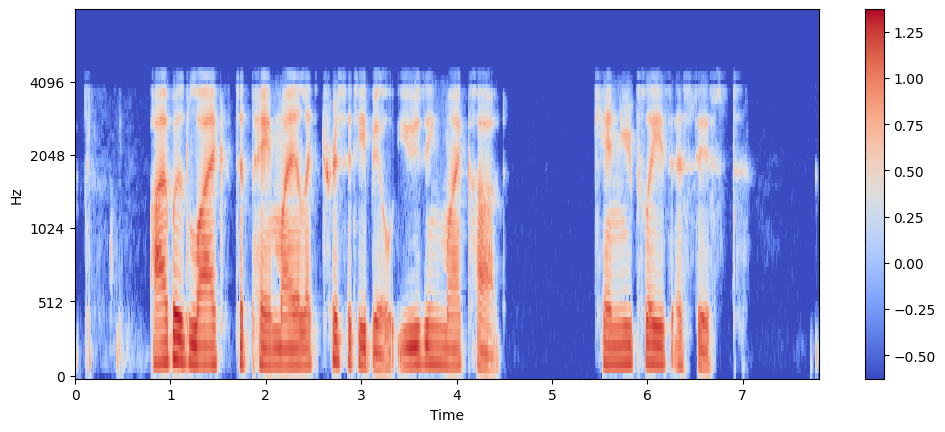

In [ ]:
# Visualize one of the examples in the minds dataset
import numpy as np
import matplotlib.pyplot as plt

example = minds[0]
input_features = example["input_features"]

plt.figure().set_figwidth(12)
librosa.display.specshow(
    np.asarray(input_features[0]),
    x_axis="time",
    y_axis="mel",
    sr=feature_extractor.sampling_rate,
    hop_length=feature_extractor.hop_length,
)
plt.colorbar()

## 3. Streaming Audio Data

* Streaming allows us to load the data progressively as we iterate over the dataset.
* Rather than downloading the whole dataset at once, we load the dataset one example at a time.
* We iterate over the dataset, loading and preparing examples **on the fly** when they are needed.

#### Streaming mode has three primary advantage:
1. **Disk space**: examples are loaded to memory one-by-one as we iterate over the dataset. Since the data is not downloaded locally, there are no disk space requirements, so you can use datasets of arbitrary size.
2. **Download and processing time**: audio datasets are large and need a significant amount of time to download and process. With streaming, loading and processing is done on the fly, meaning you can start using the dataset as soon as the first example is ready.
3. **Easy experimentation**: you can experiment on a handful of examples to check that your script works without having to download the entire dataset.

#### How can you enable streaming mode?
* Just set `streaming=True` when you load your dataset.
* [Gigaspeech](https://huggingface.co/datasets/speechcolab/gigaspeech) dataset:
  * English speech recognition corpus with 10,000 hours of high quality labeled audio suitable for supervised training.
  * The transcribed audio data is collected from audiobooks, podcasts and YouTube.

In [13]:
# GigaSpeech is a gated dataset
# We need to do two things: accept the terms on HuggingFace,
# then authenticate in Colab.

from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get("HF_TOKEN"))

In [14]:
from datasets import load_dataset

gigaspeech = load_dataset("speechcolab/gigaspeech", "xs", streaming=True)

# see structure
print(gigaspeech)


IterableDatasetDict({
    train: IterableDataset({
        features: ['segment_id', 'speaker', 'text', 'audio', 'begin_time', 'end_time', 'audio_id', 'title', 'url', 'source', 'category', 'original_full_path'],
        num_shards: 1
    })
    validation: IterableDataset({
        features: ['segment_id', 'speaker', 'text', 'audio', 'begin_time', 'end_time', 'audio_id', 'title', 'url', 'source', 'category', 'original_full_path'],
        num_shards: 1
    })
    test: IterableDataset({
        features: ['segment_id', 'speaker', 'text', 'audio', 'begin_time', 'end_time', 'audio_id', 'title', 'url', 'source', 'category', 'original_full_path'],
        num_shards: 2
    })
})


In [26]:
# We can no longer access individual samples using Python indexing
# (i.e. gigaspeech["train"][sample_idx])
# We have to iterate over the dataset

sample = next(iter(gigaspeech["train"]))
print(sample)

AttributeError: module 'sympy' has no attribute 'core'

In [27]:
# use the take() to get the first n elements
gigaspeech_head = gigaspeech["train"].take(2)
list(gigaspeech_head)

AttributeError: module 'sympy' has no attribute 'core'